Loaded shape: (101, 128, 128, 2)


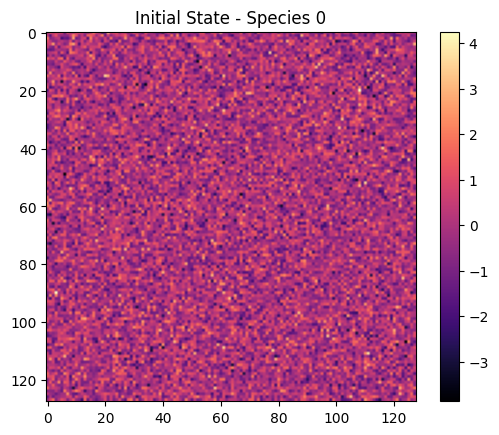

In [ ]:
import h5py
import os
#load hdf5 file
import pickle
import numpy as np
import matplotlib.pyplot as plt

file = "twoD_reaction_diffusion.hdf5"

with h5py.File(file, 'r') as f:
    all_keys = list(f.keys())
    
    # 2. Randomly choose 102 keys without replacement
    random_keys = np.random.choice(all_keys, size=102, replace=False)
    sampled_data_list = [f[key]['data'][:] for key in random_keys]
    final_samples = np.stack(sampled_data_list)
    
    # Access the 'data' dataset inside the '0000' group
    full_data = f['0000']['data'][:] 
print(f"Loaded shape: {full_data.shape}")

# Example: Plot the first time step, first species
# [time_index, x, y, species_index]
plt.imshow(full_data[ 0, :, :, 0], cmap='magma')
plt.title("Initial State - Species 0")
plt.colorbar()
plt.show()


100%|██████████| 101/101 [00:00<00:00, 1513.28it/s]


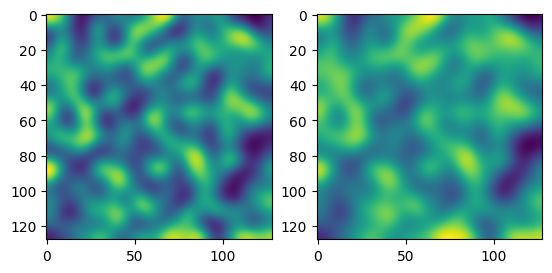

In [ ]:
from matplotlib import animation
import argparse
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from tqdm import tqdm
def visualize_2d_reacdiff(path, seed=None):
    """
    This function animates the 2D reaction-diffusion data.

    Args:
    path : path to the desired file
    seed : seed to select a specific sample/batch, ranging from 0-9999
    """

    # Read the h5 file and store the data
    h5_file = h5py.File(Path(path) / "twoD_reaction_diffusion.hdf5", "r")
    num_samples = len(h5_file.keys())

    # randomly choose a seed for picking a sample that will subsequently be visualized
    rng = np.random.default_rng()
    if not seed:
        seed = rng.integers(low=0, high=num_samples, size=1).item()

    # Ensure the seed number is defined
    assert seed < num_samples, "Seed number too high!"

    seed = str(seed).zfill(4)
    # dim = [101, 128, 128, 2]
    data = np.array(h5_file[f"{seed}/data"], dtype="f")

    h5_file.close()

    # Initialize plot
    fig, ax = plt.subplots(1, 2)

    # Store the plot handle at each time step in the 'ims' list
    ims = []
    for i in tqdm(range(data.shape[0])):
        im1 = ax[0].imshow(data[i, ..., 0].squeeze(), animated=True)
        im2 = ax[1].imshow(data[i, ..., 1].squeeze(), animated=True)
        if i == 0:
            # show an initial one first
            ax[0].imshow(data[0, ..., 0].squeeze())
            # show an initial one first
            ax[1].imshow(data[0, ..., 1].squeeze())
        ims.append([im1, im2])

    # Animate the plot
    ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

    writer = animation.PillowWriter(fps=15, bitrate=1800)
    ani.save("movie_2d_reacdiff.gif", writer=writer)
visualize_2d_reacdiff(path="./", seed=0)

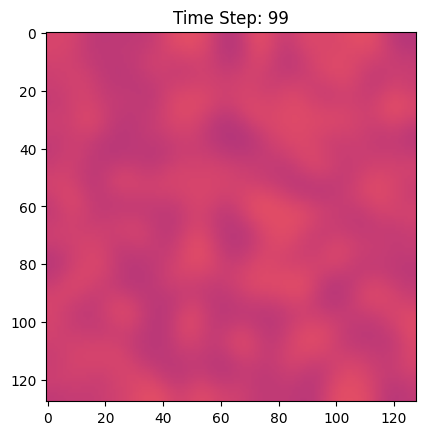

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Assuming random_samples is your data
# Shape: [samples, time, height, width, channels]
data = random_samples[0] 

fig, ax = plt.subplots()

# Initialize the plot with the first frame
im = ax.imshow(data[0][:,:,0], cmap='magma')

def update(t):
    # Update the data of the existing image object
    im.set_data(data[t][:,:,0])
    ax.set_title(f"Time Step: {t}")
    return [im]

# Create animation
# frames=100 (t from 0 to 99), interval=50ms per frame
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# To save as a GIF (requires 'pillow' or 'imagemagick' installed)
ani.save('animation.gif', writer='pillow')

# To save as an MP4 (requires 'ffmpeg' installed)
# ani.save('animation.mp4', writer='ffmpeg')

plt.show()